In [32]:
import os
from datetime import datetime
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

os.makedirs("models", exist_ok=True)

def set_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

seed = 0
set_all_seeds(seed)

In [ ]:
df = pd.read_csv(f"../../BTCUSDT-1h-data.csv")
print(df)

                  timestamp      open_time       open       high        low  \
0       2017-08-17 04:00:00  1502942400000    4261.48    4280.56    4261.48   
1       2017-08-17 04:15:00  1502943300000    4261.48    4270.41    4261.32   
2       2017-08-17 04:30:00  1502944200000    4280.00    4310.07    4267.99   
3       2017-08-17 04:45:00  1502945100000    4310.07    4313.62    4291.37   
4       2017-08-17 05:00:00  1502946000000    4308.83    4328.69    4304.31   
...                     ...            ...        ...        ...        ...   
275995  2025-07-07 00:00:00  1751846400000  109203.85  109273.07  109103.19   
275996  2025-07-07 00:15:00  1751847300000  109273.07  109288.02  108972.69   
275997  2025-07-07 00:30:00  1751848200000  109004.81  109037.82  108829.17   
275998  2025-07-07 00:45:00  1751849100000  108847.17  108922.00  108800.01   
275999  2025-07-07 01:00:00  1751850000000  108823.07  108823.08  108679.75   

            close     volume     close_time      qu

**Check missing values**

In [34]:
print(df.isnull())
print(f"Counts how many missing values there are in each column: {df.isnull().sum()}")
print(f"Total missing values: {df.isnull().sum().sum()}")

        timestamp  open_time   open   high    low  close  volume  close_time  \
0           False      False  False  False  False  False   False       False   
1           False      False  False  False  False  False   False       False   
2           False      False  False  False  False  False   False       False   
3           False      False  False  False  False  False   False       False   
4           False      False  False  False  False  False   False       False   
...           ...        ...    ...    ...    ...    ...     ...         ...   
275995      False      False  False  False  False  False   False       False   
275996      False      False  False  False  False  False   False       False   
275997      False      False  False  False  False  False   False       False   
275998      False      False  False  False  False  False   False       False   
275999      False      False  False  False  False  False   False       False   

        quote_av  trades  tb_base_av  t

**Split data**

In [ ]:
train_end_idx = int(len(df) * 0.80)

df_train = df.iloc[:train_end_idx].copy()
df_test = df.iloc[train_end_idx:].copy()

df_test.reset_index(drop=True, inplace=True)

print(f"Length of df_train: {len(df_train)}")
print(f"Length of df_test: {len(df_test)}")

Length of df_train: 240000
Length of df_test: 36000


**Building Meaningful Features**

In [36]:
def build_features(opens, highs, lows, closes, volumes, train_scalers=None):

    # Build features
    feature1 = (closes - opens) / opens
    feature2 = (highs - opens) / opens
    feature3 = (highs - closes) / closes
    feature4 = (lows - opens) / opens
    feature5 = (lows - closes) / closes
    feature6 = (highs - lows) / opens
    feature7 = (highs - lows) / closes
    feature8 = volumes

    # Stack features
    features = [
        feature1,
        feature2,
        feature3,
        feature4,
        feature5,
        feature6,
        feature7,
        feature8,
    ]
    num_features = len(features)
    scaled_fts = []

    if train_scalers is None:
        train_scalers = [MaxAbsScaler() for _ in range(num_features)]
        is_train = True
    else:
        is_train = False

    for i in range(num_features):
        # Get train scaler
        scaler = train_scalers[i]
        if is_train:
            # Scaler -> Fit -> Train dataset
            scaled_ft = scaler.fit_transform(features[i].reshape(-1, 1))
            # Save the train scaler in a list
        elif not is_train:
            # Scaler -> NOT Fit -> Test dataset
            scaled_ft = scaler.transform(features[i].reshape(-1, 1))

        # Update list of SCALED features
        scaled_fts.append(scaled_ft.flatten())

    # Stack features
    scaled_features = np.stack(scaled_fts, axis=-1)

    # Get num. features
    num_features = scaled_features.shape[-1]
    return scaled_features, num_features, train_scalers

**Example of how the scaler works**

In [37]:
import numpy as np
from sklearn.preprocessing import MaxAbsScaler

# Suppose we have a simple 1D array (e.g. daily returns)
X = np.array([ -2, -1, 0, 1, 2 ])

print("Original data:", X)

# Step 1: reshape into 2D (because sklearn expects shape (n_samples, n_features))
X_2d = X.reshape(-1, 1)

# Step 2: create the scaler and fit_transform
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X_2d)

# Step 3: flatten back to 1D for convenience
X_scaled = X_scaled.flatten()

print("Scaled data:", X_scaled)


Original data: [-2 -1  0  1  2]
Scaled data: [-1.  -0.5  0.   0.5  1. ]


**Preprocess data**

In [38]:
def preprocess_data(seq_len, df, train_scalers=None):
    m = len(df)

    opens = np.array(df['open'].values)
    highs = np.array(df['high'].values)
    lows = np.array(df['low'].values)
    closes = np.array(df['close'].values)
    volumes = np.array(df['volume'].values)

    # Build features
    features, num_features, train_scalers = build_features(opens, highs, lows, closes, volumes, train_scalers)

    # Calculate number of samples
    num_samples = m - seq_len

    # Create storage for inputs & targets
    X = np.zeros([num_samples, seq_len, num_features], dtype=np.float32)
    Y = np.zeros([num_samples, num_features], dtype=np.float32)

    # Create samples (X, Y)
    for i in range(num_samples):
        X[i] = features[i : i+seq_len]
        Y[i] = features[i+seq_len : i+seq_len+1]

    # Fix alignment
    opens = np.array(opens[seq_len:])
    closes = np.array(closes[seq_len:])

    return X, Y, num_features, opens, closes, train_scalers

In [ ]:
# Sequence Length
seq_len = 48

# Preprocess data
X_train, Y_train, num_features, _, _, train_scalers = preprocess_data(seq_len, df_train)
X_test, Y_test, num_features, backtest_opens, backtest_closes, _ = preprocess_data(seq_len, df_test, train_scalers)


In [40]:
m_train = X_train.shape[0]
m_test = X_test.shape[0]
print(f"m_train: {m_train}")
print(f"m_test: {m_test}")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

m_train: 239904
m_test: 35904
X_train shape: (239904, 96, 8)
Y_train shape: (239904, 8)
X_test shape: (35904, 96, 8)
Y_test shape: (35904, 8)


**Transform data to Torch Tensor**

In [41]:
device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')
print("my deive: ", device)

X_train = torch.from_numpy(X_train.astype(np.float32)).to(device, dtype=torch.float32)
Y_train = torch.from_numpy(Y_train.astype(np.float32)).to(device, dtype=torch.float32)

X_test = torch.from_numpy(X_test.astype(np.float32)).to(device, dtype=torch.float32)
Y_test = torch.from_numpy(Y_test.astype(np.float32)).to(device, dtype=torch.float32)

Y_pred_test = torch.zeros([m_test, num_features], device=device, dtype=torch.float32)

my deive:  cuda:0


**Build model**

In [42]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        # LSTM
        self.lstm = nn.LSTM(input_size=num_features,
                            hidden_size=64,
                            num_layers=1,
                            batch_first=True)

        # Output layer
        self.fc_out = nn.Linear(64, num_features)

    def forward(self, x):
        # LSTM
        x, (h_n, c_n) = self.lstm(x)
        x = x[:, -1, :] 

        # Output layer
        x = self.fc_out(x)
        return x



**Initialization**

In [43]:
# Initialize model
model = Model()

# Transfer model to device
model.to(device)

# Initialize criterion
criterion = nn.MSELoss()

# Choose learning rate
lr = 1e-4

# Create optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Choose batch size
batch_size = 32

# Lists of train/test losses
train_losses = []
test_losses = []

equity_epochs = []
accuracy_epochs = []

# Set epoch
num_epochs = 1000



In [44]:
def create_minibatches(X, Y, batch_size, seed, shuffle=True):

    mini_batches = []
    m = len(X)
    if shuffle:
        permutation = list(np.random.permutation(m))
        X = X[permutation]
        Y = Y[permutation]
    num_batches = m // batch_size
    for k in range(num_batches):
        mb_X = X[k * batch_size : k * batch_size + batch_size]
        mb_Y = Y[k * batch_size : k * batch_size + batch_size]
        mb_pair = (mb_X, mb_Y)
        mini_batches.append(mb_pair)

    seed += 1
    set_all_seeds(seed)

    return mini_batches, seed

**Load model (if available)**

In [ ]:
def load_training_data(model, optimizer):
    checkpoint = torch.load('training_process', weights_only=False)
    epoch = checkpoint['epoch']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']
    equity_epochs = checkpoint['equity_epochs']
    accuracy_epochs = checkpoint['accuracy_epochs']
    seed = checkpoint['seed']

    # Load model's weights & optimizer's state
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return model, optimizer, epoch, train_losses, test_losses, equity_epochs, accuracy_epochs, seed


if os.path.exists("training_process"):
    model, optimizer, epoch, train_losses, test_losses, equity_epochs, accuracy_epochs, seed = load_training_data(model, optimizer)
    print(f"Loaded model!")
else:
    print(f"No training process to load.")
    epoch = 0

Loaded model!


**Train model**

Epoch: 0, Equity: 1411.74, Accuracy: 50.33 train_losses: 0.000271051184075118, test_losses: 0.00010173003829549998, Duration: 0:00:20.031882


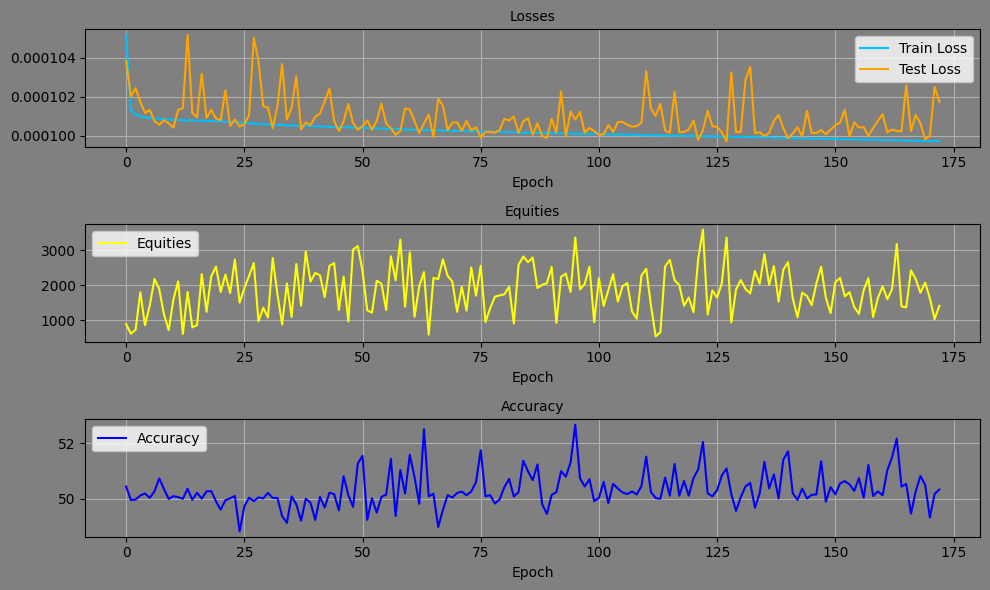

KeyboardInterrupt: 

In [ ]:
for epoch in range(epoch, num_epochs):

    # Track duration
    dt0_epoch = datetime.now()

    # Create mini batches
    mini_batches, seed = create_minibatches(X_train, Y_train, batch_size, seed, shuffle=True)

    train_losses_batch = []

    for X_train_batch, Y_train_batch in mini_batches:
        # Set train mode
        model.train()

        # Reset the gradients
        optimizer.zero_grad()

        # Forward propagation
        Y_hat_train = model(X_train_batch) # Shape: (batch_size, num_features)

        # Calculate loss (train)
        train_loss = criterion(Y_hat_train, Y_train_batch)

        # Backprop
        train_loss.backward()

        # Update optimizer
        optimizer.step()

        # Keep track of training losses
        train_losses_batch.append(train_loss.item())

    # Predict on test data
    with torch.no_grad():

        # Set evaluation mode
        model.eval()

        # # Forward propagation
        # Y_pred_test = model(X_test)

        # Forward propagation (chunks)
        while True:
            try:
                # split the test set into chunks
                chunks = 16
                m = m_test // chunks
                
                for j in range(chunks+1):
                    Y_pred_test[m*j:m*j+m] = model(X_test[m*j:m*j+m]) # Forward prop
                
                break

            except Exception as err:
                print(f"Chunks = {chunks} is too large: {err}")
                chunks += 2

        # Calculate test loss
        test_loss = criterion(Y_pred_test, Y_test)

    # Convert 'Y_pred_test' to numpy
    Y_pred_test_cpu = Y_pred_test.detach().cpu().numpy()

    train_losses.append(np.mean(train_losses_batch))
    test_losses.append(test_loss.item())

    # ===================== Backtest =====================
    equities = []    # Store equity (account value) over time
    pos_size = 1000  # Fixed position size ($1000 per trade)
    equity = 1000    # Starting capital
    correct_pred = 0 # Initialize correct prediction

    actions = Y_pred_test_cpu[:, 0] > 0 # Get model's buy/sell predictions

    for i in range(len(X_test)-1):
        curr_open = backtest_opens[i]   # the price we enter at.
        curr_close = backtest_closes[i] # the price we exit at.
        curr_action = actions[i]        # the model’s signal (buy or sell).

        # Calculate percentage price change
        pct_change = (curr_close - curr_open) / curr_open

        # Profit or loss in dollars
        pnl = np.abs(pos_size * pct_change)

        # Update equity depending on action and price move
        if curr_action == 1:     # Long position (Buy side)
            if pct_change > 0:
                equity += pnl    # Price up → profit
                correct_pred += 1
            elif pct_change < 0:
                equity -= pnl    # Price down → loss

        elif curr_action == 0:   # Short position
            if pct_change > 0:
                equity -= pnl    # Price up → loss
            elif pct_change < 0:
                equity += pnl    # Price down → profit
                correct_pred += 1

        equities.append(equity) # Save current equity
    # ========================================================

    # Calculate percentage accuracy
    accuracy = correct_pred / len(X_test) * 100

    # Save final equity for each epoch
    equity_epochs.append(equity)
    accuracy_epochs.append(accuracy)

    print(f'Epoch: {epoch}, Equity: {equity:.2f}, Accuracy: {accuracy:.2f} train_losses: {train_losses[-1]}, test_losses: {test_losses[-1]}, Duration: {datetime.now() - dt0_epoch}')

    # Save training process
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'test_losses': test_losses,
        'equity_epochs': equity_epochs,
        'accuracy_epochs': accuracy_epochs,
        'seed': seed,
    }, 'training_process')

    if equity > 1200:
        torch.save(model.state_dict(), f"models/eq_{equity:.0f}_ep_{epoch}.pt")

    # Plot training process
    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 6))
    scaler_testloss = MinMaxScaler(feature_range=(np.min(test_losses)-0.0000000001, np.max(test_losses)))

    # Plot Train Loss and Test Loss
    axs[0].set_title(f"Losses", fontsize=10)
    axs[0].plot(scaler_testloss.fit_transform(np.array(train_losses).reshape(-1,1)), label='Train Loss', color='deepskyblue')
    axs[0].plot(test_losses, label='Test Loss', color='orange')
    axs[0].set_xlabel("Epoch")
    axs[0].legend()
    axs[0].grid()
    # Plot Equities
    axs[1].set_title(f"Equities", fontsize=10)
    axs[1].plot(equity_epochs, label='Equities', color='yellow')
    axs[1].set_xlabel("Epoch")
    axs[1].legend()
    axs[1].grid()
    # Plot Accuracy
    axs[2].set_title(f"Accuracy", fontsize=10)
    axs[2].plot(accuracy_epochs, label='Accuracy', color='blue')
    axs[2].set_xlabel("Epoch")
    axs[2].legend()
    axs[2].grid()
    # Set background color and paper color
    fig.patch.set_facecolor(mcolors.to_hex('grey'))  # Set paper color
    for ax in axs.flat:
        ax.set_facecolor(mcolors.to_hex('grey'))  # Set bg color
    # Display
    plt.tight_layout()
    plt.savefig(f'training_process.png')
    plt.show()
    plt.close()